In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import smarts_cerebellum.globals as gl

cst = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_FaMap', 'summary_MNISymC_CST_FaMap.tsv'), sep = '\t')
mcp = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_FaMap', 'summary_MNISymC_MCP_FaMap.tsv'), sep = '\t')

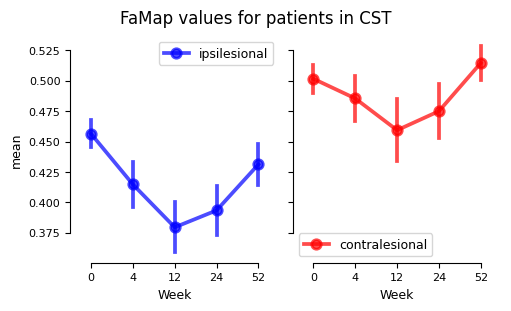

In [2]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, sharex = True, constrained_layout = True)
sns.pointplot(x = 'Week', y = 'mean', data = cst[cst.group == 'ipsilesional'], alpha = .7, label = f'ipsilesional', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'Week', y = 'mean', data = cst[cst.group == 'contralesional'], alpha = .7, label = f'contralesional', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'FaMap values for patients in CST')
plt.legend()
sns.despine(trim = True)
plt.show()

In [13]:
from scipy import stats

print(f'---t-test between ipsilesional and contralesional CST patients--- \n')

for week in cst.Week.unique():
    t_val, p_val = stats.ttest_rel(cst[(cst.Week == week) & (cst.regionname == f'CSTR')]['mean'], cst[(cst.Week == week) & (cst.regionname == f'CSTL')]['mean'])
    print(f'Week {week}: t-value = {t_val}, p-value = {p_val} \n')
    

---t-test between ipsilesional and contralesional CST patients--- 

Week 0: t-value = -3.9392762526932876, p-value = 0.002778131941949696 

Week 4: t-value = -7.052948273347755, p-value = 2.7307868716828188e-06 

Week 12: t-value = -5.898340722935204, p-value = 3.8791825338380154e-05 

Week 24: t-value = -7.243312292209156, p-value = 2.862737382900045e-06 

Week 52: t-value = -6.933276691277527, p-value = 0.00012042426284649332 



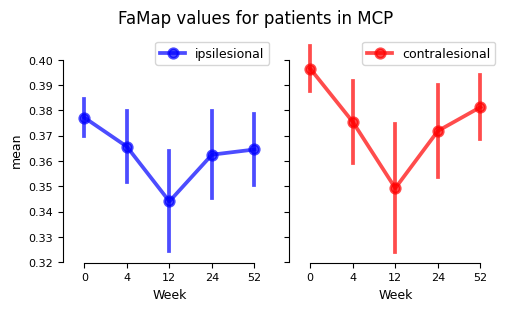

In [3]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, sharex = True, constrained_layout = True)
sns.pointplot(x = 'Week', y = 'mean', data = mcp[mcp.group == 'ipsilesional'], alpha = .7, label = f'ipsilesional', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'Week', y = 'mean', data = mcp[mcp.group == 'contralesional'], alpha = .7, label = f'contralesional', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'FaMap values for patients in MCP')
plt.legend()
sns.despine(trim = True)
plt.show()